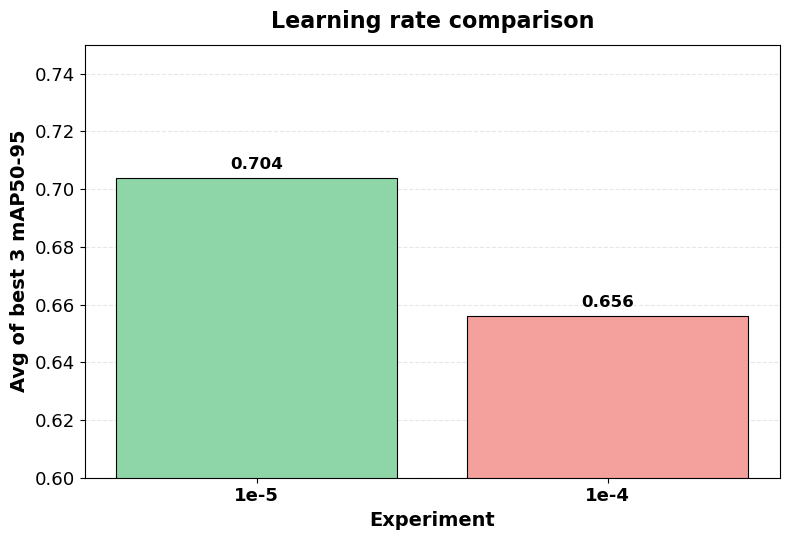

Top-K averages: {'1e-5': 0.7038648659126815, '1e-4': 0.6559256276563254}
Using columns:
 - sam_bbox_finetune_initial - val/mAP_0.50_0.95 
 - sam_bbox_finetune_initial_lr1e-4 - val/mAP_0.50_0.95


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "wandb_exp1_map5095.csv"  # <-- change if needed
K = 3  # <-- choose K

df = pd.read_csv(csv_path)

# Ensure Step is numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Keep only steps <= 50
df = df[df["Step"] <= 500].copy()

# Keep only main columns (exclude __MIN/__MAX and Step)
metric_cols = [
    c for c in df.columns
    if c != "Step" and not c.endswith("__MIN") and not c.endswith("__MAX")
]

def topk_mean(series: pd.Series, k: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(s.nlargest(min(k, len(s))).mean())

# Identify the two columns
col_lr_1e4 = [c for c in metric_cols if "sam_bbox_finetune_initial_lr1e-4" in c][0]
col_initial = [c for c in metric_cols if c == "sam_bbox_finetune_initial - val/mAP_0.50_0.95"][0]

scores = {
    "1e-5": topk_mean(df[col_initial], K),
    "1e-4": topk_mean(df[col_lr_1e4], K),
}

# --- Plot ---
labels = ["1e-5", "1e-4"]
values = [scores[l] for l in labels]

colors = {
    "1e-5": "#8ED6A8",
    "1e-4": "#F4A09C",
}

plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    labels,
    values,
    color=[colors[l] for l in labels],
    edgecolor="black",
    linewidth=0.8
)

# Value labels
for b in bars:
    h = b.get_height()
    if np.isfinite(h):
        plt.text(
            b.get_x() + b.get_width() / 2,
            h + 0.002,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

plt.ylim(0.6, 0.75)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Experiment", fontsize=14, fontweight="bold")
plt.ylabel(f"Avg of best {K} mAP50-95", fontsize=14, fontweight="bold")
plt.title("Learning rate comparison", fontsize=16, fontweight="bold", pad=12)

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

print("Top-K averages:", scores)
print("Using columns:\n -", col_initial, "\n -", col_lr_1e4)

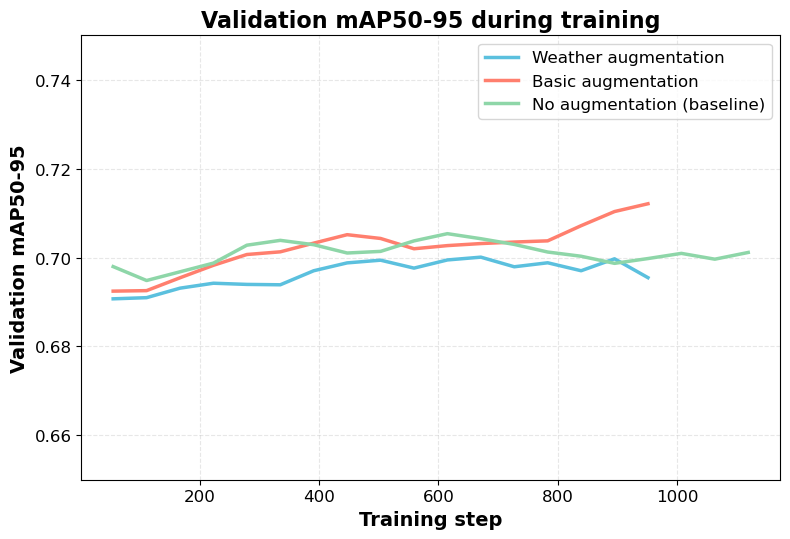

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_exp2_map5095.csv"
df = pd.read_csv(csv_path)

# Ensure Step numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Extract columns
col_weather = "sam_bbox_finetune_aug_weather_lr1e-5 - val/mAP_0.50_0.95"
col_basic = "sam_bbox_finetune_aug_basic_lr1e-5 - val/mAP_0.50_0.95"
col_initial = "sam_bbox_finetune_initial - val/mAP_0.50_0.95"

# Colors
colors = {
    "weather": "#5BC0DE",
    "basic": "#FF7F6E",
    "baseline": "#8ED6A8"
}

# --- smoothing ---
smooth_window = 3
weather_s = df[col_weather].rolling(smooth_window, min_periods=1).mean()
basic_s = df[col_basic].rolling(smooth_window, min_periods=1).mean()
initial_s = df[col_initial].rolling(smooth_window, min_periods=1).mean()

plt.figure(figsize=(8,5.5))

plt.plot(
    df["Step"], weather_s,
    label="Weather augmentation",
    color=colors["weather"],
    linewidth=2.5
)

plt.plot(
    df["Step"], basic_s,
    label="Basic augmentation",
    color=colors["basic"],
    linewidth=2.5
)

plt.plot(
    df["Step"], initial_s,
    label="No augmentation (baseline)",
    color=colors["baseline"],
    linewidth=2.5
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Training step", fontsize=14, fontweight="bold")
plt.ylabel("Validation mAP50-95", fontsize=14, fontweight="bold")
plt.title("Validation mAP50-95 during training", fontsize=16, fontweight="bold")

plt.ylim(0.65, 0.75)  # <-- requested range

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

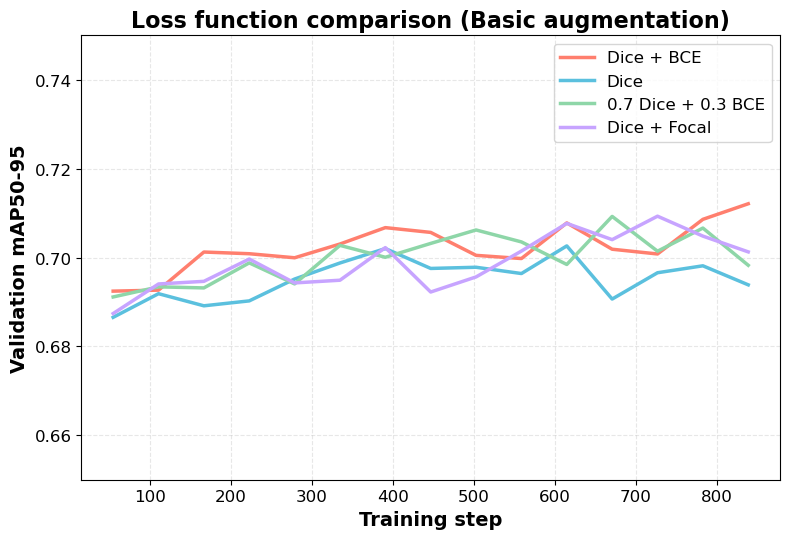

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_exp3_map5095.csv"
df = pd.read_csv(csv_path)

# Ensure Step numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Extract columns
col_dice_focal = "sam_bbox_finetune_aug_basic_lr1e-5_loss_dice_focal - val/mAP_0.50_0.95"
col_dice07_bce03 = "sam_bbox_finetune_aug_basic_lr1e-5_loss_dice07_bce03 - val/mAP_0.50_0.95"
col_dice = "sam_bbox_finetune_aug_basic_lr1e-5_loss_dice - val/mAP_0.50_0.95"
col_basic = "sam_bbox_finetune_aug_basic_lr1e-5 - val/mAP_0.50_0.95"

# Colors by loss
colors = {
    "dice_bce": "#FF7F6E",   # soft coral
    "dice": "#5BC0DE",          # cyan
    "dice_weighted": "#8ED6A8", # soft green
    "dice_focal": "#C7A4FF"     # soft purple
}

# --- smoothing ---
smooth_window = 1
dice_focal_s = df[col_dice_focal].rolling(smooth_window, min_periods=1).mean()
dice07_bce03_s = df[col_dice07_bce03].rolling(smooth_window, min_periods=1).mean()
dice_s = df[col_dice].rolling(smooth_window, min_periods=1).mean()
basic_s = df[col_basic].rolling(smooth_window, min_periods=1).mean()

plt.figure(figsize=(8,5.5))

plt.plot(
    df["Step"], basic_s,
    label="Dice + BCE",
    color=colors["dice_bce"],
    linewidth=2.5
)

plt.plot(
    df["Step"], dice_s,
    label="Dice",
    color=colors["dice"],
    linewidth=2.5
)

plt.plot(
    df["Step"], dice07_bce03_s,
    label="0.7 Dice + 0.3 BCE",
    color=colors["dice_weighted"],
    linewidth=2.5
)

plt.plot(
    df["Step"], dice_focal_s,
    label="Dice + Focal",
    color=colors["dice_focal"],
    linewidth=2.5
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Training step", fontsize=14, fontweight="bold")
plt.ylabel("Validation mAP50-95", fontsize=14, fontweight="bold")
plt.title("Loss function comparison (Basic augmentation)", fontsize=16, fontweight="bold")

plt.ylim(0.65, 0.75)

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

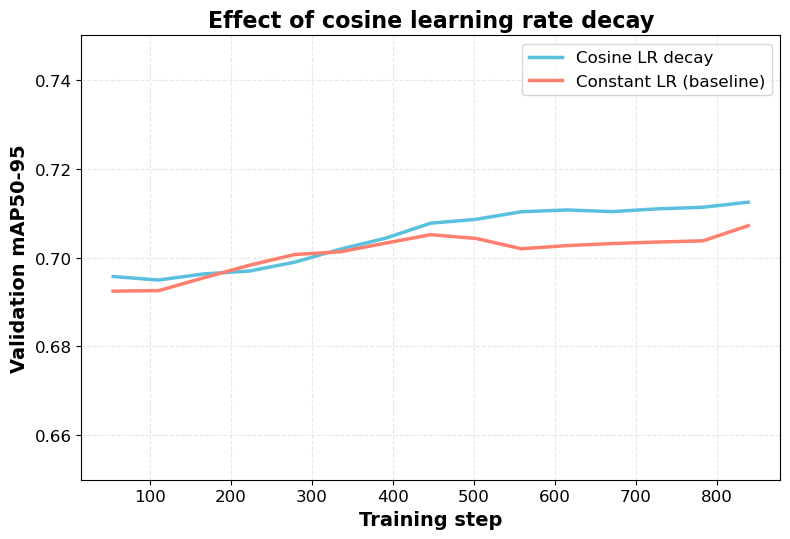

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_exp4_map5095.csv"
df = pd.read_csv(csv_path)

# Ensure Step numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Extract columns
col_cosdecay = "sam_bbox_finetune_aug_basic_lr1e-5_lrcosdecay - val/mAP_0.50_0.95"
col_basic = "sam_bbox_finetune_aug_basic_lr1e-5 - val/mAP_0.50_0.95"

# Colors
colors = {
    "cosdecay": "#5BC0DE",   # cyan
    "baseline": "#FF7F6E"    # coral
}

# --- smoothing ---
smooth_window = 3
cosdecay_s = df[col_cosdecay].rolling(smooth_window, min_periods=1).mean()
basic_s = df[col_basic].rolling(smooth_window, min_periods=1).mean()

plt.figure(figsize=(8,5.5))

plt.plot(
    df["Step"], cosdecay_s,
    label="Cosine LR decay",
    color=colors["cosdecay"],
    linewidth=2.5
)

plt.plot(
    df["Step"], basic_s,
    label="Constant LR (baseline)",
    color=colors["baseline"],
    linewidth=2.5
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Training step", fontsize=14, fontweight="bold")
plt.ylabel("Validation mAP50-95", fontsize=14, fontweight="bold")
plt.title("Effect of cosine learning rate decay", fontsize=16, fontweight="bold")

plt.ylim(0.65, 0.75)

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

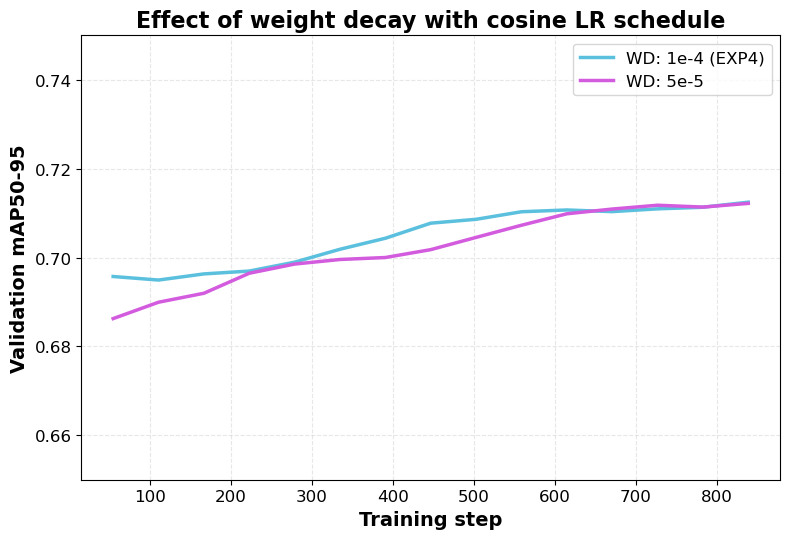

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_exp5_map5095.csv"
df = pd.read_csv(csv_path)

# Ensure Step numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Extract columns
col_wd = "sam_bbox_finetune_aug_basic_lr1e-5_lrcosdecay_wd_5e-5 - val/mAP_0.50_0.95"
col_cosdecay = "sam_bbox_finetune_aug_basic_lr1e-5_lrcosdecay - val/mAP_0.50_0.95"

# Colors
colors = {
    "wd":  "#D35BDE",       # cyan
    "baseline": "#5BC0DE"
}

# --- smoothing ---
smooth_window = 3
wd_s = df[col_wd].rolling(smooth_window, min_periods=1).mean()
cosdecay_s = df[col_cosdecay].rolling(smooth_window, min_periods=1).mean()

plt.figure(figsize=(8,5.5))

plt.plot(
    df["Step"], cosdecay_s,
    label="WD: 1e-4 (EXP4)",
    color=colors["baseline"],
    linewidth=2.5
)

plt.plot(
    df["Step"], wd_s,
    label="WD: 5e-5",
    color=colors["wd"],
    linewidth=2.5
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Training step", fontsize=14, fontweight="bold")
plt.ylabel("Validation mAP50-95", fontsize=14, fontweight="bold")
plt.title("Effect of weight decay with cosine LR schedule", fontsize=16, fontweight="bold")

plt.ylim(0.65, 0.75)

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

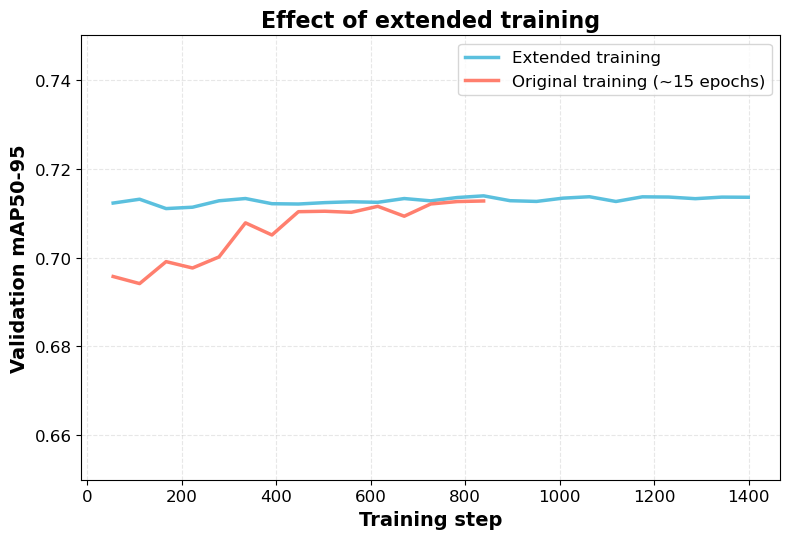

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "wandb_expfinal2_map5095.csv"
df = pd.read_csv(csv_path)

# Ensure Step numeric
df["Step"] = pd.to_numeric(df["Step"], errors="coerce")

# Extract columns
col_long = "sam_bbox_finetune_aug_basic_lr1e-5_lrcosdecay_long - val/mAP_0.50_0.95"
col_short = "sam_bbox_finetune_aug_basic_lr1e-5_lrcosdecay - val/mAP_0.50_0.95"

# Colors
colors = {
    "long": "#5BC0DE",   # cyan
    "short": "#FF7F6E"   # coral
}

# --- smoothing ---
smooth_window = 1
long_s = df[col_long].rolling(smooth_window, min_periods=1).mean()
short_s = df[col_short].rolling(smooth_window, min_periods=1).mean()

plt.figure(figsize=(8,5.5))

plt.plot(
    df["Step"], long_s,
    label="Extended training",
    color=colors["long"],
    linewidth=2.5
)

plt.plot(
    df["Step"], short_s,
    label="Original training (~15 epochs)",
    color=colors["short"],
    linewidth=2.5
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.xlabel("Training step", fontsize=14, fontweight="bold")
plt.ylabel("Validation mAP50-95", fontsize=14, fontweight="bold")
plt.title("Effect of extended training", fontsize=16, fontweight="bold")

plt.ylim(0.65, 0.75)

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()